In [1]:
# ── Cell 2
# Core utilities
import os
import time
import warnings
import random
from argparse import Namespace

# Data & Numerical Computing
import numpy as np

# Plotting & Visualization
import matplotlib.pyplot as plt

# JAX Framework
import jax
import jax.numpy as jnp
from jax import random as jax_random


# ─────────────────────────────────────────────────────────────────────────────
# Global Configuration & Seeding
# ─────────────────────────────────────────────────────────────────────────────

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

# Global JAX random key (used across all cells, including main())
JAX_KEY = None

def seed_everything(seed=42):
    """Set global seed for reproducibility across NumPy, Python random, and JAX."""
    global JAX_KEY
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    JAX_KEY = jax_random.PRNGKey(seed)

# Initialize global seed (this JAX_KEY will be used in main() function)
seed_everything(42)

# ─────────────────────────────────────────────────────────────
print('✓ All required libraries imported and configured.')

✓ All required libraries imported and configured.


In [2]:
# ── Cell 3 (physical system)

# System and data configuration
DIMENSION, OMEGA = 1, 1.0
DAMPING_COEFF = 0.02  # Friction coefficient (matches GLNN paper)
N_TRAJECTORIES = 40   # Number of trajectories
PTS_PER_TRAJECTORY = 201  # Points per trajectory
H_DATA_GEN = 0.05  # Time step for data generation (matches paper)

def rk4_step(q, dynamics_fn, dt):
    """Perform a single RK4 integration step.

    Args:
        q: Current state
        dynamics_fn: Function that computes state derivatives
        dt: Time step

    Returns:
        q_new: Updated state after RK4 step
        deriv: Derivative at current state
    """
    k1 = dynamics_fn(q)
    k2 = dynamics_fn(q + 0.5 * dt * k1)
    k3 = dynamics_fn(q + 0.5 * dt * k2)
    k4 = dynamics_fn(q + dt * k3)

    q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    deriv = dynamics_fn(q)  # Derivative at current state

    return q_new, deriv

def _damped_HO_trajectory(n_points, d, omega=1.0, damping=1.0, dt=0.05, q0=None):
    """Generate a single trajectory using RK4 integration (JAX).

    Equation of Motion: q̈ = -ω²*q - a*q̇

    Args:
        n_points (int): Number of time steps to integrate
        d (int): Degrees of freedom (state dimension = 2*d: [q, q̇])
        omega (float): Natural frequency (default=1.0)
        damping (float): Damping coefficient (default=1.0)
        dt (float): Time step for RK4 integration (default=0.05)
        q0 (jnp.ndarray, optional): Initial state [q₀, q̇₀]. If None, randomly initialized from Uniform[-1,1]²

    Returns:
        tuple:
            - states (jnp.ndarray): Shape (n_points, 2*d) - full trajectory [q, q̇] at each time step (open rollout)
            - derivs (jnp.ndarray): Shape (n_points-1, 2*d) - state derivatives [q̇, q̈] at each time step (open rollout)
    """
    if q0 is None:
        # JAX: uniform initialization using global JAX_KEY
        q0 = jax_random.uniform(JAX_KEY, shape=(2 * d,), minval=-1.0, maxval=1.0)

    def dynamics(state):
        """Compute state derivatives: [q̇, q̈]"""
        q_pos, q_vel = state[:d], state[d:]
        q_acc = -omega**2 * q_pos - damping * q_vel
        return jnp.concatenate([q_vel, q_acc])

    states = [q0]
    derivs = []
    q = q0

    for _ in range(n_points - 1):
        q_new, deriv = rk4_step(q, dynamics, dt)
        states.append(q_new)
        derivs.append(deriv)
        q = q_new

    return jnp.stack(states), jnp.stack(derivs)

# def _damped_HO_trajectory(n_points, d, omega=1.0, damping=1.0, dt=0.05, q0=None):
#     """Generate a single trajectory using RK4 integration (JAX).

#     Equation of Motion (Simple Pendulum): q̈ = -ω²*sin(q) - a*q̇

#     Args:
#         n_points (int): Number of time steps to integrate
#         d (int): Degrees of freedom (state dimension = 2*d: [q, q̇])
#         omega (float): Natural frequency sqrt(g/L) (default=1.0)
#         damping (float): Damping coefficient (default=1.0)
#         dt (float): Time step for RK4 integration (default=0.05)
#         q0 (jnp.ndarray, optional): Initial state [q₀, q̇₀]. If None, randomly initialized from Uniform[-1,1]²

#     Returns:
#         tuple:
#             - states (jnp.ndarray): Shape (n_points, 2*d) - full trajectory [q, q̇] at each time step
#             - derivs (jnp.ndarray): Shape (n_points-1, 2*d) - state derivatives [q̇, q̈] at each time step
#     """
#     if q0 is None:
#         # JAX: uniform initialization using global JAX_KEY
#         q0 = jax_random.uniform(JAX_KEY, shape=(2 * d,), minval=-1.0, maxval=1.0)

#     def dynamics(state):
#         """Compute state derivatives: [q̇, q̈]"""
#         q_pos, q_vel = state[:d], state[d:]
#         # Changed to Pendulum dynamics: added jnp.sin() to q_pos
#         q_acc = -omega**2 * jnp.sin(q_pos) - damping * q_vel
#         return jnp.concatenate([q_vel, q_acc])

#     states = [q0]
#     derivs = []
#     q = q0

#     for _ in range(n_points - 1):
#         q_new, deriv = rk4_step(q, dynamics, dt)
#         states.append(q_new)
#         derivs.append(deriv)
#         q = q_new

#     return jnp.stack(states), jnp.stack(derivs)

print('Configured Damped Harmonic Motion Data (Paper Baseline) - JAX:')
print(f'  State: {DIMENSION}D [q, q_dot] | ω: {OMEGA} | a (damping): {DAMPING_COEFF}')
print(f'  Trajectories: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} points = {N_TRAJECTORIES * PTS_PER_TRAJECTORY} point pairs')
print(f'  Initial conditions: Uniform in [-1, 1]²')


Configured Damped Harmonic Motion Data (Paper Baseline) - JAX:
  State: 1D [q, q_dot] | ω: 1.0 | a (damping): 0.02
  Trajectories: 40 × 201 points = 8040 point pairs
  Initial conditions: Uniform in [-1, 1]²


In [3]:
# ── Cell 4: Generate & Normalize Synthetic Data

print('Generating damped harmonic motion data (40 trajectories × 200 points)...')

all_states = []
all_derivs = []

for traj_idx in range(N_TRAJECTORIES):
    states, derivs = _damped_HO_trajectory(
        PTS_PER_TRAJECTORY, DIMENSION,
        omega=OMEGA, damping=DAMPING_COEFF, dt=H_DATA_GEN
    )
    all_states.append(np.array(states))
    all_derivs.append(np.array(derivs))

# For plotting purposes, one trajectory data is kept aside
gt_trajectory = all_states[0]
gt_derivatives = all_derivs[0]
gt_initial_condition = gt_trajectory[0]

# Training & Test Data
x_data = np.concatenate([states[:-1] for states in all_states], axis=0)
# y_data = np.concatenate([derivs for derivs in all_derivs], axis=0)
y_data = np.concatenate([states[1:] for states in all_states], axis=0)

split_idx = len(x_data) // 2
x_tr, y_tr = x_data[:split_idx], y_data[:split_idx]
x_te, y_te = x_data[split_idx:], y_data[split_idx:]

print(f"""✓ Data generated: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} = {len(x_data)} pairs
  Train/Test: {len(x_tr)} / {len(x_te)}
  Reference trajectory (Trajectory 0): q₀={gt_initial_condition[0]:.4f}, q̇₀={gt_initial_condition[1]:.4f}""")

Generating damped harmonic motion data (40 trajectories × 200 points)...
✓ Data generated: 40 × 201 = 8000 pairs
  Train/Test: 4000 / 4000
  Reference trajectory (Trajectory 0): q₀=-0.0226, q̇₀=0.3596


In [4]:
# ── Cell 5
# Verify and summarize damped harmonic motion data

pos_vel_corr = np.corrcoef(x_tr[:, 0], x_tr[:, 1])[0, 1]
deriv_stats = y_tr.mean(axis=0), y_tr.std(axis=0)

print(f"""--- Damped Harmonic Motion Data Summary ---
Physics Setup:
  System: 1D Damped Harmonic Oscillator
  EOM: q̈ + aq̇ + ω²q = 0  (where a={DAMPING_COEFF}, ω={OMEGA})
  Initial conditions: Uniform in [-1, 1]²

Dataset Configuration (matches GLNN paper Table 1):
  Trajectories: {N_TRAJECTORIES}
  Points per trajectory: {PTS_PER_TRAJECTORY}
  Time step (dt): {H_DATA_GEN}
  Total point pairs: {len(x_data)}
  Train/Test split: 1:1 → Train={len(x_tr)}, Test={len(x_te)}

[Raw Statistics: Mean | Std | Min | Max]
  Position q:  {x_tr[:, 0].mean():.4f} | {x_tr[:, 0].std():.4f} | {x_tr[:, 0].min():.4f} | {x_tr[:, 0].max():.4f}
  Velocity q̇: {x_tr[:, 1].mean():.4f} | {x_tr[:, 1].std():.4f} | {x_tr[:, 1].min():.4f} | {x_tr[:, 1].max():.4f}

[Derivative (Target) Statistics]
  Mean: {deriv_stats[0].round(6)}
  Std:  {deriv_stats[1].round(6)}

[Physics Verification]
  Position-Velocity correlation: {pos_vel_corr:.4f} (weak, expected for oscillatory motion)
  Velocity magnitude (train): mean={np.abs(x_tr[:, 1]).mean():.4f}, std={np.abs(x_tr[:, 1]).std():.4f}
-------------------------------------------""")

--- Damped Harmonic Motion Data Summary ---
Physics Setup:
  System: 1D Damped Harmonic Oscillator
  EOM: q̈ + aq̇ + ω²q = 0  (where a=0.02, ω=1.0)
  Initial conditions: Uniform in [-1, 1]²

Dataset Configuration (matches GLNN paper Table 1):
  Trajectories: 40
  Points per trajectory: 201
  Time step (dt): 0.05
  Total point pairs: 8000
  Train/Test split: 1:1 → Train=4000, Test=4000

[Raw Statistics: Mean | Std | Min | Max]
  Position q:  0.0648 | 0.2276 | -0.3433 | 0.3542
  Velocity q̇: -0.0121 | 0.2478 | -0.3487 | 0.3599

[Derivative (Target) Statistics]
  Mean: [ 0.064122 -0.015306]
  Std:  [0.228089 0.247096]

[Physics Verification]
  Position-Velocity correlation: 0.0336 (weak, expected for oscillatory motion)
  Velocity magnitude (train): mean=0.2245, std=0.1056
-------------------------------------------


Total dataset size    : 4000 points
Active points (>1e-4) : 4000 points
Dead points (≤1e-4)   : 0 (0.00%)


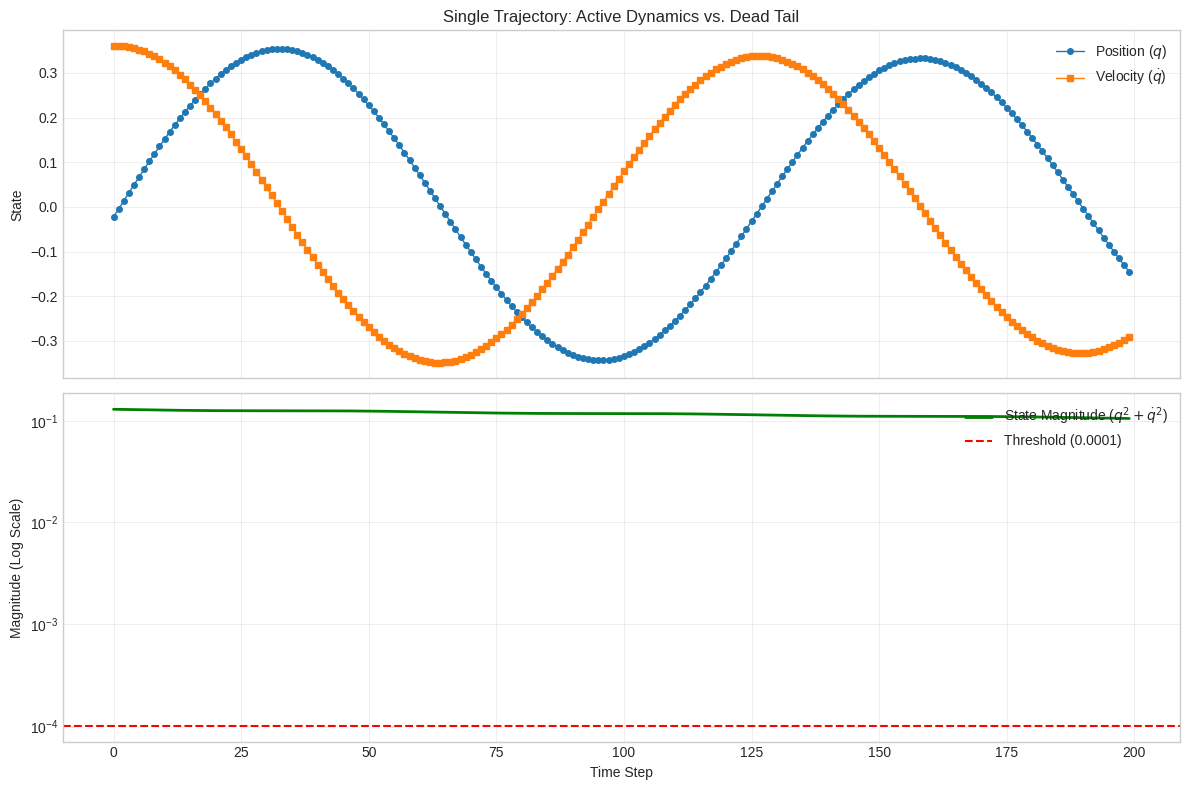

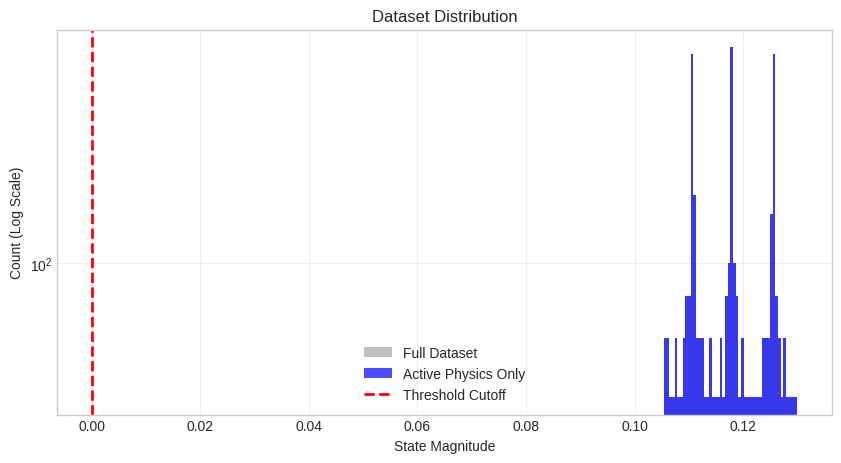

In [5]:
# ── Cell 6 (Energy Threshold Analysis in JAX)
energy_threshold = 1e-4

# Convert to JAX arrays for computation
x_tr_jax = jnp.array(x_tr)

# 1. Calculate state magnitude (JAX)
state_magnitude_jax = jnp.sum(x_tr_jax**2, axis=-1)
state_magnitude = np.array(state_magnitude_jax)  # Convert back for plotting

# 2. Identify active vs dead points (JAX)
active_indices_jax = state_magnitude_jax > energy_threshold
active_indices = np.array(active_indices_jax)  # Convert back to numpy

# Print the analysis stats
orig_size = len(x_tr)
new_size = int(np.sum(active_indices))
print(f"Total dataset size    : {orig_size} points")
print(f"Active points (>1e-4) : {new_size} points")
print(f"Dead points (≤1e-4)   : {orig_size - new_size} ({(1 - new_size/orig_size)*100:.2f}%)")

# Visualization
time_steps = PTS_PER_TRAJECTORY - 1
single_traj = x_tr[:time_steps]
single_mag = state_magnitude[:time_steps]
is_active = active_indices[:time_steps]
cutoff_idx = int(jnp.argmax(~is_active)) if not is_active.all() else time_steps

# --- Plot A: Time Series & Cutoff ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
t = np.arange(time_steps)

ax1.plot(t, single_traj[:, 0], label='Position ($q$)', color='#1f77b4', linewidth=1, marker='o', markersize=4)
ax1.plot(t, single_traj[:, 1], label='Velocity ($\\dot{q}$)', color='#ff7f0e', linewidth=1, marker='s', markersize=4)
if cutoff_idx < time_steps:
    ax1.axvspan(cutoff_idx, time_steps, color='red', alpha=0.15, label='Dead Tail Region')
ax1.set_ylabel('State')
ax1.set_title('Single Trajectory: Active Dynamics vs. Dead Tail')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Plot B: Magnitude Threshold ---
ax2.plot(t, single_mag, label='State Magnitude ($q^2 + \\dot{q}^2$)', color='green', linewidth=2)
ax2.axhline(energy_threshold, color='red', linestyle='--', label=f'Threshold ({energy_threshold})')
if cutoff_idx < time_steps:
    ax2.axvspan(cutoff_idx, time_steps, color='red', alpha=0.15)
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Magnitude (Log Scale)')
ax2.set_yscale('log')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot C: Dataset Distribution Histogram ---
plt.figure(figsize=(10, 5))
mag_active = state_magnitude[active_indices]
plt.hist(state_magnitude, bins=50, alpha=0.5, label='Full Dataset', color='gray')
plt.hist(mag_active, bins=50, alpha=0.7, label='Active Physics Only', color='blue')
plt.axvline(energy_threshold, color='red', linestyle='dashed', linewidth=2, label='Threshold Cutoff')
plt.yscale('log')
plt.title('Dataset Distribution')
plt.xlabel('State Magnitude')
plt.ylabel('Count (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# ── Cell 7
import flax.linen as nn

DOF = 1           # Degrees of freedom (x, y, z, roll, pitch, yaw)
H   = 1.0/30.0    # DT for JIGSAWS dataset
EPS = 1e-3        # Mass matrix regularization

# ─────────────────────────────────────────────────────────────────────────────
# 1) Lagrangian Network (L-net)
# ─────────────────────────────────────────────────────────────────────────────
class LagrangianNet(nn.Module):
    """
    Lagrangian Network: Maps (q, q̇) → scalar Lagrangian L = T - U

    Architecture (from GLNN paper Section 4.2):
      - 3-layer fully connected network
      - Hidden dimension: 200
      - Activation: Softplus
      - Output initialization: N(0, 1e-4)
    """
    hidden_dim: int = 200

    @nn.compact
    def __call__(self, q, q_t):
        # Concat q and q_dot
        x = jnp.concatenate([q, q_t], axis=-1)

        # Hidden layers with Softplus activation
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)

        # Output layer: scalar Lagrangian
        # Weight ~ N(0, 1e-4), Bias = 0.0
        x = nn.Dense(
            features=1,
            kernel_init=jax.nn.initializers.normal(stddev=1e-4),
            bias_init=jax.nn.initializers.constant(0.0)
        )(x)

        return jnp.squeeze(x, axis=-1)

# ─────────────────────────────────────────────────────────────────────────────
# 2) Force Library Network (replaces ForceNet)
# ─────────────────────────────────────────────────────────────────────────────
class ForceLibraryNet(nn.Module):
    """
    Force Library Network: Combines physics-inspired force terms via a linear layer.

    Features (φ):
      1. q              → Position/spring forces
      2. q̇             → Velocity-dependent forces
      3. tanh(10*q̇)    → Smooth approximation of sign(q̇) for Coulomb friction
      4. M⁻¹∇_qL       → Contribution from Lagrangian gradient

    Output: w·φ + b (scalar force for each DOF)
    """
    output_dim: int = 1

    @nn.compact
    def __call__(self, q, q_t, l_grad_q, l_hess_q_t_q_t):
        """
        Compute non-conservative force from physics-informed library features.

        Args:
            q: Position
            q_t: Velocity
            l_grad_q: Gradient of Lagrangian w.r.t. position
            l_hess_q_t_q_t: Hessian of Lagrangian w.r.t. velocity

        Returns:
            Force prediction shape (..., output_dim)
        """
        # ───────────────────────────────────────────────────────────────────
        # Construct Force Library Features (φ)
        # ───────────────────────────────────────────────────────────────────

        # 1. Position term
        phi_q = q

        # 2. Velocity term
        phi_q_dot = q_t

        # 3. Smooth sign approximation (Coulomb friction)
        phi_q_sign = jnp.tanh(10.0 * q_t)

        # 4. M⁻¹ ∇_q L term
        mass_matrix = l_hess_q_t_q_t
        m_inv = jnp.linalg.pinv(mass_matrix)
        phi_m_inv_dL_dq = jnp.einsum('...ij,...j->...i', m_inv, l_grad_q)

        # Concatenate all library terms: φ = [q, q̇, tanh(10*q̇), M⁻¹∇_qL]
        phi = jnp.concatenate([phi_q, phi_q_dot, phi_q_sign, phi_m_inv_dL_dq], axis=-1)

        # ───────────────────────────────────────────────────────────────────
        # Apply Linear Combiner to Library Features
        # ───────────────────────────────────────────────────────────────────

        # F_nc = w·φ + b (linear combiner on library features)
        x = nn.Dense(
            features=self.output_dim,
            kernel_init=jax.nn.initializers.normal(stddev=1e-4),
            bias_init=jax.nn.initializers.constant(0.0),
            name='force_combiner'  # <--- ADD THIS NAME
        )(phi)
        return x

# ─────────────────────────────────────────────────────────────────────────────
# 3) Hybrid GLNN with both L-net and F-net
# ─────────────────────────────────────────────────────────────────────────────
class HybridGLNNMASS:
    """
    Generalized Lagrangian Neural Network (GLNN) for non-conservative systems.
    Implements the generalized Lagrange equation:
        q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F_nc]
    where:
      - L: Lagrangian learned by L-net
      - F_nc: Non-conservative forces from a physics-informed library:
              F_nc = w·[q, q̇, tanh(10*q̇), M⁻¹∇_qL] + b (clamped to [-10, 10])
    """
    def __init__(self, d, hidden_dim=200, total_systems=5):
        self.d = d
        self.total_systems = total_systems
        self.l_net = LagrangianNet(hidden_dim=hidden_dim)
        self.force_lib_net = ForceLibraryNet(output_dim=d)

    def init(self, key, dummy_x):
        """Initialize L-net and Force Library Network parameters deterministically."""

        # ── 1. THE FIX: Deterministic Key Generation ─────────────────────────────
        # Instead of jax.random.split, we vmap fold_in over the system indices.
        # System 'i' always gets the exact same key, regardless of self.total_systems.
        indices = jnp.arange(self.total_systems)
        keys = jax.vmap(lambda i: jax.random.fold_in(key, i))(indices)
        # ─────────────────────────────────────────────────────────────────────────

        # Extract one sample for initialization
        q, q_t = jnp.split(dummy_x[0], 2, axis=-1)

        # Initialize L-net
        l_params = jax.vmap(self.l_net.init, in_axes=(0, None, None))(keys, q, q_t)

        # Initialize Force Library ensemble with properly shaped dummy inputs
        dummy_l_grad_q = jnp.zeros_like(q)            # Shape: (d,)
        dummy_l_hess_q_t_q_t = jnp.eye(self.d)        # Shape: (d, d)

        force_lib_params = jax.vmap(self.force_lib_net.init, in_axes=(0, None, None, None, None))(
            keys, q, q_t, dummy_l_grad_q, dummy_l_hess_q_t_q_t
        )
        return {'l_net': l_params, 'force_lib_net': force_lib_params}

    # def dstate(self, x, params):
    def _dstate_single(self, x, params):
        """
        Core Physics: Processes exactly ONE state vector `x` for ONE system.
        Compute state derivatives using the generalized Lagrange equation.
        Args:
            x: State vector [q, q̇] with shape (d,) or (batch, d)
            params: Dict containing 'l_net' and 'f_net' parameters
        Returns:
            State derivative [q̇, q̈]
        """
        q, q_t = jnp.split(x, 2, axis=-1)        # Split state back into q and q_t

        # Define pure functions for autodiff
        def lagrangian(q, q_t): return self.l_net.apply(params['l_net'], q, q_t)
        def force(q, q_t,  l_grad_q, l_hess_q_t_q_t): return self.force_lib_net.apply(params['force_lib_net'], q, q_t, l_grad_q, l_hess_q_t_q_t)

        # 2. Compute Lagrangian derivatives
        l_grad_q = jax.grad(lagrangian, 0)(q, q_t)              # ∂L/∂q
        l_hess_q_t_q_t = jax.hessian(lagrangian, 1)(q, q_t)     # ∇q̇∇_q̇ L  # mass_matrix
        l_grad_q_grad_q_t = jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t) # ∇_q∇_q̇ L

        l_hess_q_t_q_t = l_hess_q_t_q_t + (1e-6 * jnp.eye(l_hess_q_t_q_t.shape[-1]))

        # 3. Compute non-conservative force
        F_nc = force(q, q_t, l_grad_q, l_hess_q_t_q_t)

        # 4. Generalized Lagrange equation
        # q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F]
        rhs = l_grad_q - (l_grad_q_grad_q_t @ q_t) + F_nc
        q_tt = jnp.linalg.pinv(l_hess_q_t_q_t) @ rhs # Solve for acceleration using pseudo-inverse for numerical stability

        # Return state derivative [q̇, q̈]
        return jnp.concatenate([q_t, q_tt], axis=-1)

    def dstate(self, x_batch, m_ensemble):
        """
        Public API to compute state derivatives for ALL systems across a BATCH of data.
        Args:
            x_batch: Shape (Batch, Features). The input data.
            m_ensemble: PyTree where every parameter array has a leading dimension
                        of size `total_systems`.
        Returns:
            Output shape: (total_systems, Batch, Features)
        """
        # Step 1: Define how ONE system (m) processes the ENTIRE batch.
        # in_axes=(0, None) means: map over x_batch (axis 0), keep 'm' the same (None)
        def dstate_sys(m): return jax.vmap(self._dstate_single, in_axes=(0, None))(x_batch, m)

        # Step 2: Map that batch-processing function over ALL systems in the ensemble.
        # This takes our PyTree `m_ensemble`, slices off one system's parameters at a time,
        # runs the entire batch through it, and stacks the results.
        return jax.vmap(dstate_sys, in_axes=0)(m_ensemble)

    # def forward(self, x, params):
    def _forward_single_system(self, x_batch, params_single_system):
        """Forward pass: compute one-step RK4 integration.
        params_single_system: Has NO ensemble dimension."""
        def batched_dstate(x_b): return jax.vmap(self._dstate_single, in_axes=(0, None))(x_b, params_single_system)
        dt = H_DATA_GEN  # 0.05
        q_next, _ = rk4_step(x_batch, batched_dstate, dt)
        return q_next
        # return self.dstate(x, params)

    def forward(self, x_batch, m_ensemble):
        """
        Public API: Run ALL systems on the SAME batch of inputs simultaneously.
        x_batch shape: (Batch, Features)
        m_ensemble: PyTree with leading dim `total_systems`
        Returns shape: (total_systems, Batch, Features), Features=(q, q_dot)
        """
        return jax.vmap(self._forward_single_system, in_axes=(None, 0))(x_batch, m_ensemble)

# ── Logging ──────────────────────────────────────────────────────────────────
print(f'GLNN configured : DOF={DOF}  dt={float(H):.4f}s  EPS={EPS}')
print(f'L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)')
print(f'F-net           : 3x Dense(200)-Softplus → {DOF}D (Non-conservative Forces)')

GLNN configured : DOF=1  dt=0.0333s  EPS=0.001
L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)
F-net           : 3x Dense(200)-Softplus → 1D (Non-conservative Forces)


In [13]:
# ── Cell 8
#  Training with 4-Stage Curriculum Learning (PyTorch) ──────────

import optax
from functools import partial
import flax.traverse_util as traverse_util

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def loss_fn(params, model, xb, yb, delta_scale, l2_coef, l1_coef):
    """
    Computes the curriculum loss for a single system using K-step rollout.

    Args:
        params: PyTree of model weights.
        model: Flax module instance to provide the forward method.
        xb, yb: (Batch, Features) inputs/targets for single-step loss.
        delta_scale: is the standard deviation of your target variables.
        l2_coef: Coefficient applied to L2 weight decay.

    Returns:
        total_loss: The blended, regularized scalar loss for gradient computation.
        loss_k: The raw K-step rollout Sc-MSE used for logging.
    """
    # 1. Forward pass for ALL systems
    # preds shape: (total_systems, Batch, Features)
    preds = model.forward(xb, params)

    # 2. MSE per system (yb automatically broadcasts to all systems)
    errors = ((preds-yb)/ delta_scale)**2
    system_losses = jnp.mean(errors, axis=(1, 2)) # Shape: (total_systems,)
    base_loss = jnp.sum(system_losses)

    # 3. The Consensus loss term
    # If the models agree completely, variance is 0.
    # If they diverge, variance grows, and we penalize it.
    pred_variance = jnp.var(preds, axis=0)           # Shape: (Batch, Features)
    consensus_weight = 0.01
    consensus_loss = consensus_weight*jnp.mean(pred_variance)         # Reduced to a single scalar

    # 4. Global Regularization
    l2_reg = sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

    # 5. Targeted L1 Regularization (Applies ONLY to force_combiner)
    # Flatten the nested dictionary with '/' separators (e.g., 'params/ForceNet_0/force_combiner/kernel')
    flat_params = traverse_util.flatten_dict(params, sep='/')
    l1_reg = 0.0

    # Search for the specific kernel weights belonging to our named layer
    for path, weight in flat_params.items():
        if 'force_combiner' in path and 'kernel' in path:
            l1_reg += jnp.sum(jnp.abs(weight))

    # 6. Final optimization target
    total_loss = base_loss + consensus_loss + (l2_coef * l2_reg) + (l1_coef * l1_reg)
    return total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── JIT Compiled Update Step ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@partial(jax.jit, static_argnames=['model', 'tx'])
def update_step(model, tx, params, opt_state, xb, yb, delta_scale, l2_coef, l1_coef):
    """Calculates gradients, updates optimizer, and returns new params in a pure function."""
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    # Pass the new l1_coef to the gradient function
    (total_loss, system_losses), grads = grad_fn(
        params, model, xb, yb, delta_scale, l2_coef, l1_coef
    )

    # Optimizer step (clipping done in def main)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Training Loop ────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def train_loop(model, tx, params, opt_state, iter_count, Xs, Ys, delta_scale, key, training_start, batch_size):
    max_idx = len(Xs) - 1
    key, subkey = jax.random.split(key)
    start_idxs = jax.random.randint(subkey, (batch_size,), 0, max_idx)

    xb = Xs[start_idxs]
    yb = Ys[start_idxs]

    # Optimization Step (Updates all models)
    key, dropout_key = jax.random.split(key)
    params, opt_state, total_loss, sys_losses = update_step(
        model, tx, params, opt_state, xb, yb, delta_scale, 1e-5, 1e-5
    )

    if iter_count % 500 == 0:
        total_loss.block_until_ready()
        total_elapsed = time.perf_counter() - training_start
        # Format individual system losses for printing
        sys_loss_str = ", ".join([f"{l:.2e}" for l in sys_losses])
        print(
            f"[Iter {iter_count:5d}] "
            f"Comb_Loss: {total_loss:.2e} | "
            f"Sys MSEs: [{sys_loss_str}] | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return params, opt_state, total_loss, iter_count, key

def main(args, delta_scale, Xs, Ys):
    print(f'Device: {jax.devices()[0]}')
    print(f'Ensemble Size: {args.total_systems} systems')

    # 1. Initialize Batched Model State
    model = HybridGLNNMASS(d=args.dimension, total_systems=args.total_systems)

    key = JAX_KEY
    key, init_key = jax.random.split(key)

    # If d=1, features=2 (q, q_dot)
    dummy_x = jnp.ones((args.batch_size, args.dimension * 2))
    params = model.init(init_key, dummy_x)

    loss_history = []
    global_iter = 1
    training_start = time.perf_counter()

    print(f'\n━━━ Training System ━━━')

    # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
    print(f'Stage 1: Warmup ({args.iterations_1} iterations)')

    # optax linear schedule equivalent to PyTorch's LinearLR
    schedule1 = optax.linear_schedule(
        init_value=args.lr * 0.1,
        end_value=args.lr,
        transition_steps=args.iterations_1
    )
    tx1 = optax.adamw(learning_rate=schedule1, weight_decay=1e-4) # PyTorch had 1e-4
    tx1 = optax.chain(
        optax.clip_by_global_norm(100.0),
        optax.adamw(learning_rate=schedule1, weight_decay=1e-4)
    )
    opt_state1 = tx1.init(params)

    for step in range(args.iterations_1):
        params, opt_state1, avg_loss, global_iter, key = train_loop(
            model, tx1, params, opt_state1, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    # # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
    # print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')
    # schedule2 = optax.cosine_decay_schedule(init_value=args.lr, decay_steps=args.iterations_2)
    # tx2 = optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    # opt_state2 = tx2.init(params)

    # for step in range(args.iterations_2):
    #     params, opt_state2, avg_loss, global_iter, key = train_loop(
    #         model, tx2, params, opt_state2, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
    #     )
    #     loss_history.append(float(avg_loss))

    print(f'\n✅ Ensemble Training complete.')
    return np.array(loss_history), params, model

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION (JAX) ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# JAX automatically selects the fastest available accelerator (GPU/TPU)
device = jax.devices()[0]
print(f"Using device: {device}")

delta_scale = y_tr.std(axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

Xs = jnp.array(x_tr, dtype=jnp.float32)
Ys = jnp.array(y_tr, dtype=jnp.float32)
delta_scale_jax = jnp.array(delta_scale, dtype=jnp.float32)

# Create training configuration
# Note: total_systems and l1_weight are omitted here as we simplified
# the architecture to a single system with L2-only regularization previously.
args = Namespace(
    dimension=1,         # Degrees of freedom (d=1 means state size is 2: q, q_dot)
    total_systems=3,
    lr=3e-4,             # Peak learning rate
    iterations_1=10000,   # Warmup steps
    iterations_2=3000,   # Fine-tuning steps
    batch_size=512,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training
print(f'\n{"="*80}')
print(f'{"STARTING MASS ENSEMBLE TRAINING":^80}')
print(f'{"="*80}')

training_start = time.perf_counter()

loss_arr, final_params, dnn = main(args, delta_scale_jax, Xs, Ys)

loss_arr = np.array(loss_arr)
total_time = time.perf_counter() - training_start

print(f'{"="*80}')
print(f'Training complete in {total_time/60:.2f} minutes.')
print(f'Model object is available as `dnn`.')
print(f'Model weights are available as `final_params`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')

Using device: cuda:0

                        STARTING MASS ENSEMBLE TRAINING                         
Device: cuda:0
Ensemble Size: 3 systems

━━━ Training System ━━━
Stage 1: Warmup (10000 iterations)
[Iter   500] Comb_Loss: 1.15e-02 | Sys MSEs: [3.62e-07, 2.02e-07, 3.23e-07] | Total Time: 0.29 min
[Iter  1000] Comb_Loss: 1.05e-02 | Sys MSEs: [2.46e-07, 1.15e-07, 2.41e-07] | Total Time: 0.45 min
[Iter  1500] Comb_Loss: 9.28e-03 | Sys MSEs: [4.34e-07, 1.64e-07, 1.56e-07] | Total Time: 0.61 min
[Iter  2000] Comb_Loss: 8.02e-03 | Sys MSEs: [1.38e-07, 3.60e-08, 1.15e-07] | Total Time: 0.78 min
[Iter  2500] Comb_Loss: 6.80e-03 | Sys MSEs: [8.83e-08, 2.44e-08, 8.65e-08] | Total Time: 0.95 min
[Iter  3000] Comb_Loss: 5.66e-03 | Sys MSEs: [5.19e-08, 2.86e-09, 2.02e-07] | Total Time: 1.11 min
[Iter  3500] Comb_Loss: 4.65e-03 | Sys MSEs: [1.83e-07, 1.71e-07, 4.20e-07] | Total Time: 1.27 min
[Iter  4000] Comb_Loss: 3.81e-03 | Sys MSEs: [2.02e-08, 2.69e-05, 2.43e-08] | Total Time: 1.43 min
[Iter

In [14]:
# ── Cell 9: Evaluation Utilities + Wrapper (JAX) ─────────────────────────

class EvalWrapper:
    def __init__(self, model, params, system_idx=0):
        """
        Binds the Flax model and trained parameters together for easier evaluation.
        Extracts ONLY the parameters for a specific system (default 0) to save compute.
        """
        self.model = model

        # Slices the PyTree to grab the parameters for just ONE system in the ensemble
        self.single_params = jax.tree_util.tree_map(lambda x: x[system_idx], params)

        # JIT compile batched versions of the single-system functions
        # _dstate_single expects (Features,), so we vmap it to handle (Batch, Features)
        self.batched_dstate = jax.jit(
            lambda x, p: jax.vmap(self.model._dstate_single, in_axes=(0, None))(x, p)
        )

        # _forward_single_system natively handles (Batch, Features)
        self.batched_forward = jax.jit(
            lambda x, p: self.model._forward_single_system(x, p)
        )

    def _format_input(self, x):
        """Ensures the input is a JAX array and adds a batch dim if necessary."""
        x = jnp.array(x, dtype=jnp.float32)
        is_single = (x.ndim == 1)
        if is_single:
            x = x[None, :]  # Shape (1, Features)
        return x, is_single

    def dstate(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_dstate(x, self.single_params)
        return out[0] if is_single else out

    def __call__(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_forward(x, self.single_params)
        return out[0] if is_single else out


def one_step_mse_jax(wrapper, x_data, y_data):
    """Compute one-step MSE prediction error."""
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)

    # Wrapper handles batching automatically
    pred = wrapper(x_data)
    mse = jnp.mean((pred - y_data) ** 2)

    return float(mse)


@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout(model, single_params, x0_batched, n_steps):
    """Internal JIT-compiled loop for lightning fast rollouts on a single system."""
    def step_fn(current_state, _):
        next_state = model._forward_single_system(current_state, single_params)
        return next_state, next_state

    # lax.scan loops n_steps - 1 times efficiently on the GPU
    _, trajectory = jax.lax.scan(step_fn, x0_batched, None, length=n_steps - 1)

    # Prepend the initial state to the trajectory
    return jnp.concatenate([x0_batched[None, :], trajectory], axis=0)


def rollout_jax(wrapper, x0, n_steps):
    """Generate rollout trajectory starting from x0 for n_steps."""
    x0 = jnp.array(x0, dtype=jnp.float32)

    # Ensure x0 is batched (1, Features) for the _compiled_rollout
    if x0.ndim == 1:
        x0 = x0[None, :]

    # Run compiled rollout
    traj = _compiled_rollout(wrapper.model, wrapper.single_params, x0, n_steps)

    # Drop the batch dimension for the final output array and convert to numpy
    return np.array(traj[:, 0, :])

print("✓ Evaluation utilities loaded (JAX simplified wrapper - Single System Evaluation).")

✓ Evaluation utilities loaded (JAX simplified wrapper - Single System Evaluation).


In [15]:
# ── Cell 10: ODE-Integrated Rollout ─────────────────────────────────────────

from scipy.integrate import solve_ivp
import numpy as np

# Flatten the 3D data (Traj, Time, Feat) -> 2D (Total_Points, Feat) for the single-step MSE pass
x_tr_flat = x_tr.reshape(-1, x_tr.shape[-1])
y_tr_flat = y_tr.reshape(-1, y_tr.shape[-1])
x_te_flat = x_te.reshape(-1, x_te.shape[-1])
y_te_flat = y_te.reshape(-1, y_te.shape[-1])

# Evaluate on training and test sets (one-step predictions)
# Automatically find the system_idx with the lowest training MSE
sys_mses = [one_step_mse_jax(EvalWrapper(dnn, final_params, system_idx=i), x_tr_flat, y_tr_flat) for i in range(args.total_systems)]
best_sys_idx = int(np.argmin(sys_mses))
print(f"Automatically selected best_sys_idx: {best_sys_idx} (Train MSE: {sys_mses[best_sys_idx]:.4e})\n")

# We pass the trained params and explicitly select system_idx=0 from the MASS ensemble
eval_model = EvalWrapper(dnn, final_params, system_idx=best_sys_idx)
# eval_model = EvalWrapper(dnn, final_params, system_idx=0)

mse_tr = one_step_mse_jax(eval_model, x_tr_flat, y_tr_flat)
mse_te = one_step_mse_jax(eval_model, x_te_flat, y_te_flat)

print(f'One-Step MSE:')
print(f'  Train: {mse_tr:.4e}')
print(f'  Test:  {mse_te:.4e}')
print(f'  Gap:   {(mse_te/mse_tr - 1)*100:.1f}%')

def lnn_dynamics_wrapper(t, state_vec):
    """
    Wrapper for Scipy ODE solver: converts (q, q̇) to [q̇, q̈_predicted] using JAX.
    """
    # eval_model.dstate handles the JAX array conversion and evaluation
    dstate_pred = eval_model.dstate(state_vec)

    # solve_ivp expects standard numpy float arrays
    return np.array(dstate_pred)

# Integrate the LNN from the reference initial condition
t_span = (0.0, (len(gt_trajectory) - 1) * H_DATA_GEN)
t_eval = np.arange(len(gt_trajectory)) * H_DATA_GEN

print(f"\n✓ Integrating LNN dynamics using ODE solver:")
print(f"  Initial condition: q={gt_initial_condition[0]:.4f}, q̇={gt_initial_condition[1]:.4f}")
print(f"  Integration time: t ∈ [{t_span[0]:.3f}, {t_span[1]:.3f}] seconds")
print(f"  Number of evaluation points: {len(t_eval)}")

# # Solve the ODE
# sol = solve_ivp(
#     lnn_dynamics_wrapper,
#     t_span,
#     gt_initial_condition.flatten(),
#     t_eval=t_eval,
#     method='DOP853',
#     dense_output=False,
#     max_step=H_DATA_GEN
# )

# if sol.status != 0:
#     print(f"⚠️  ODE solver warning: {sol.message}")

# # Extract integrated trajectory
# traj_pred = sol.y.T  # Transpose to (n_steps, 2)
# traj_gt = gt_trajectory

# print(f"✓ ODE integration complete: {len(traj_pred)} timesteps")

Automatically selected best_sys_idx: 0 (Train MSE: 2.9813e-09)

One-Step MSE:
  Train: 2.9813e-09
  Test:  2.9813e-09
  Gap:   0.0%

✓ Integrating LNN dynamics using ODE solver:
  Initial condition: q=-0.0226, q̇=0.3596
  Integration time: t ∈ [0.000, 10.000] seconds
  Number of evaluation points: 201


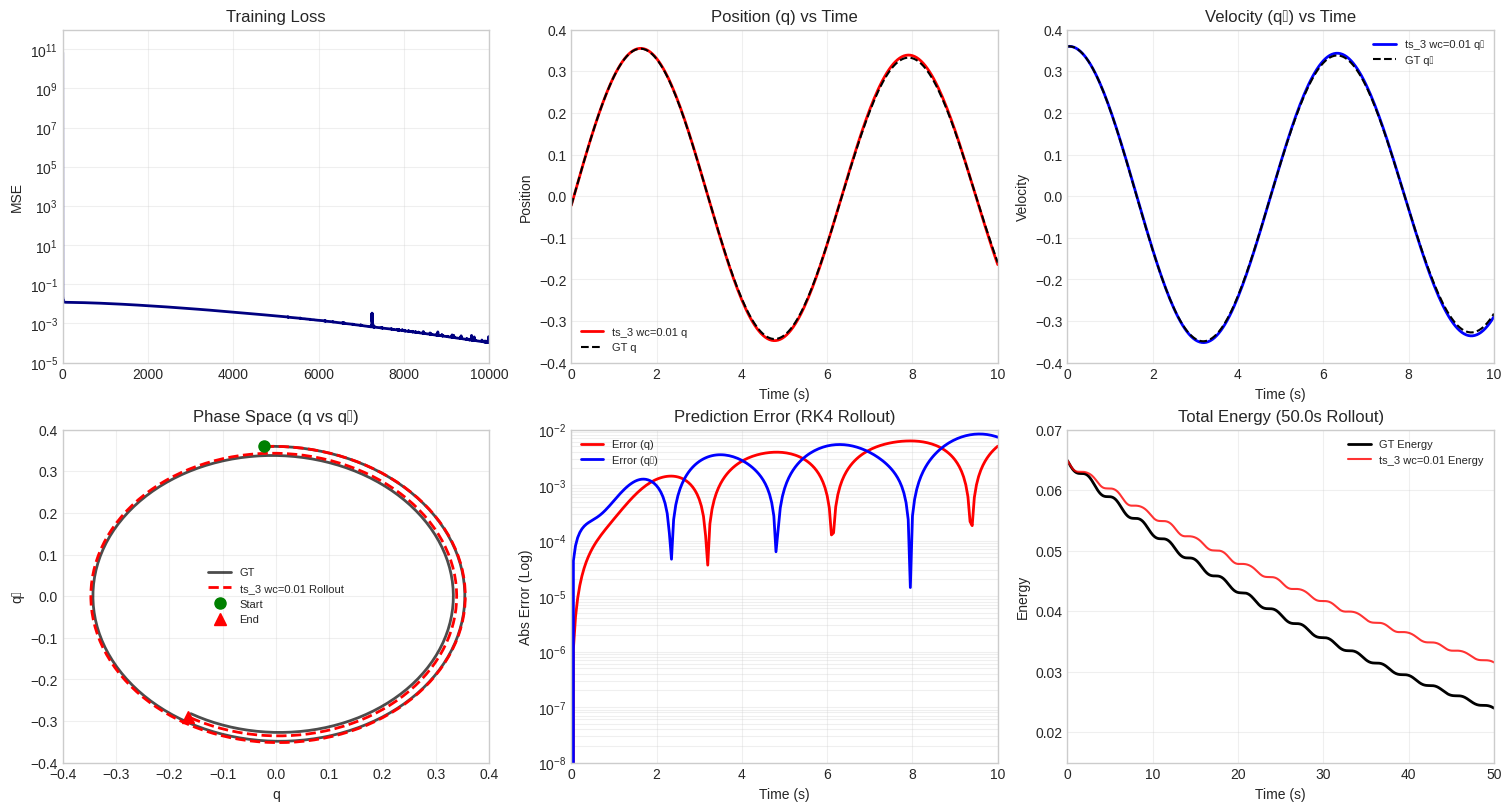


         DAMPED HARMONIC OSCILLATOR - RK4 ROLLOUT DIAGNOSTICS         
Model:                ts_3 wc=0.01
Short Trajectory:     201 timesteps (10.050 s)
Mean position error:  2.4320e-03
Max position error:   6.2720e-03
Mean velocity error:  2.8393e-03
Max velocity error:   8.3508e-03
----------------------------------------------------------------------
Long Trajectory (E):  1001 timesteps (50.000 s)
System: ω=1.00, damping=0.0200

Ground Truth Energy Evolution:
  Initial energy: 0.064909
  Final energy:   0.023996
  Energy loss:    0.040913 (63.03%)

Model Predicted Energy Evolution:
  Initial energy: 0.064909
  Final energy:   0.031559
  Energy drift:   -0.033350
  Energy loss:    0.033350 (51.38%)

Energy Prediction Error:
  Mean error:     4.901806e-03
  Max error:      7.563507e-03



In [16]:
# ── Cell 11: Visualization & Diagnostics (DAMPED HARMONIC OSCILLATOR) ──────

# ── Dynamic Label Formatting ─────────────────────────────────────────────
# Assumes total_systems and consensus_weight are in scope
total_systems = args.total_systems
consensus_weight = 0.01
mod_lbl = f"ts_{total_systems} wc={consensus_weight}"

# 1. Short Rollout for Standard Plots

n_steps = len(gt_trajectory)
dt = H_DATA_GEN

# Use the JIT-compiled JAX rollout (Replaces the slow Python for-loop!)
traj_pred = rollout_jax(eval_model, gt_initial_condition, n_steps)

# Ensure GT inputs are standard NumPy arrays for plotting
loss_arr = np.asarray(loss_arr)
traj_gt = np.asarray(gt_trajectory)
time_axis = np.arange(n_steps) * dt

q_pred, q_dot_pred = traj_pred[:, 0], traj_pred[:, 1]
q_gt, q_dot_gt = traj_gt[:, 0], traj_gt[:, 1]

# 2. Long Rollout (50 seconds) for Energy Comparison

t_max_long = 50.0
long_steps = int(t_max_long / dt)

# Generate long Ground Truth using the dataset generator
long_gt_states, _ = _damped_HO_trajectory(
    long_steps + 1, DIMENSION,
    omega=OMEGA,
    damping=DAMPING_COEFF,
    dt=dt,
    q0=gt_initial_condition
)
long_gt_states = np.asarray(long_gt_states)

# Generate long GLNN Rollout using JAX
long_pred_states = rollout_jax(
    eval_model,
    gt_initial_condition,
    long_steps + 1
)

time_axis_long = np.arange(long_steps + 1) * dt

q_gt_long, q_dot_gt_long = long_gt_states[:, 0], long_gt_states[:, 1]
q_pred_long, q_dot_pred_long = long_pred_states[:, 0], long_pred_states[:, 1]

# 3. Create Figure

fig, axs = plt.subplots(
    2, 3,
    figsize=(15, 8),
    constrained_layout=True
)

# ────────────────────────────────────────────────────────────────────────
# 1) Training Loss
# ────────────────────────────────────────────────────────────────────────

axs[0, 0].semilogy(loss_arr, 'navy', lw=2)
axs[0, 0].set(
    title='Training Loss',
    ylabel='MSE'
)
axs[0, 0].set_xlim(0, 10000)
axs[0, 0].set_ylim(1e-5, 1e12)
axs[0, 0].grid(True, alpha=0.3)


# ────────────────────────────────────────────────────────────────────────
# 2) Position vs Time (Short)
# ────────────────────────────────────────────────────────────────────────

axs[0, 1].plot(
    time_axis,
    q_pred,
    'r-',
    lw=2,
    label=f'{mod_lbl} q'
)

axs[0, 1].plot(
    time_axis,
    q_gt,
    'k--',
    lw=1.5,
    label='GT q'
)

axs[0, 1].set(
    title='Position (q) vs Time',
    xlabel='Time (s)',
    ylabel='Position'
)

axs[0, 1].set_xlim(0, 10)
axs[0, 1].set_ylim(-0.4, 0.4)
axs[0, 1].legend(fontsize=8)
axs[0, 1].grid(True, alpha=0.3)


# ────────────────────────────────────────────────────────────────────────
# 3) Velocity vs Time (Short)
# ────────────────────────────────────────────────────────────────────────

axs[0, 2].plot(
    time_axis,
    q_dot_pred,
    'b-',
    lw=2,
    label=f'{mod_lbl} q̇'
)

axs[0, 2].plot(
    time_axis,
    q_dot_gt,
    'k--',
    lw=1.5,
    label='GT q̇'
)

axs[0, 2].set(
    title='Velocity (q̇) vs Time',
    xlabel='Time (s)',
    ylabel='Velocity'
)

axs[0, 2].set_xlim(0, 10)
axs[0, 2].set_ylim(-0.4, 0.4)
axs[0, 2].legend(fontsize=8)
axs[0, 2].grid(True, alpha=0.3)


# ────────────────────────────────────────────────────────────────────────
# 4) Phase Space (Short)
# ────────────────────────────────────────────────────────────────────────

axs[1, 0].plot(
    q_gt,
    q_dot_gt,
    'k-',
    lw=2,
    label='GT',
    alpha=0.7
)

axs[1, 0].plot(
    q_pred,
    q_dot_pred,
    'r--',
    lw=2,
    label=f'{mod_lbl} Rollout'
)

axs[1, 0].plot(
    q_pred[0],
    q_dot_pred[0],
    'go',
    ms=8,
    label='Start'
)

axs[1, 0].plot(
    q_pred[-1],
    q_dot_pred[-1],
    'r^',
    ms=8,
    label='End'
)

axs[1, 0].set(
    title='Phase Space (q vs q̇)',
    xlabel='q',
    ylabel='q̇'
)

axs[1, 0].set_xlim(-0.4, 0.4)
axs[1, 0].set_ylim(-0.4, 0.4)
axs[1, 0].legend(fontsize=8)
axs[1, 0].grid(True, alpha=0.3)


# ────────────────────────────────────────────────────────────────────────
# 5) Absolute Error (Short)
# ────────────────────────────────────────────────────────────────────────

abs_err_q = np.abs(q_pred - q_gt)
abs_err_q_dot = np.abs(q_dot_pred - q_dot_gt)

axs[1, 1].semilogy(
    time_axis,
    abs_err_q,
    'r-',
    lw=2,
    label='Error (q)'
)

axs[1, 1].semilogy(
    time_axis,
    abs_err_q_dot,
    'b-',
    lw=2,
    label='Error (q̇)'
)

axs[1, 1].set(
    title='Prediction Error (RK4 Rollout)',
    xlabel='Time (s)',
    ylabel='Abs Error (Log)'
)

axs[1, 1].set_xlim(0, 10)
axs[1, 1].set_ylim(1e-8, 1e-2)
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid(True, alpha=0.3, which='both')


# ────────────────────────────────────────────────────────────────────────
# 6) Energy Calculation for Long Sequence
# ────────────────────────────────────────────────────────────────────────
# For damped harmonic oscillator:
# E = 1/2 q̇² + 1/2 ω² q²

energy_gt_long = (
    0.5 * (q_dot_gt_long**2)
    + 0.5 * (OMEGA**2) * (q_gt_long**2)
)

energy_pred_long = (
    0.5 * (q_dot_pred_long**2)
    + 0.5 * (OMEGA**2) * (q_pred_long**2)
)

np.save(
    f"long_energy_ts_{total_systems}_wc={consensus_weight}.npy",
    {
        'time': time_axis_long,
        'energy_gt': energy_gt_long,
        'energy_pred': energy_pred_long
    },
    allow_pickle=True
)

axs[1, 2].plot(
    time_axis_long,
    energy_gt_long,
    'k-',
    lw=2,
    label='GT Energy'
)

axs[1, 2].plot(
    time_axis_long,
    energy_pred_long,
    'r-',
    lw=1.5,
    alpha=0.8,
    label=f'{mod_lbl} Energy'
)

axs[1, 2].set(
    title=f'Total Energy ({t_max_long}s Rollout)',
    xlabel='Time (s)',
    ylabel='Energy'
)

axs[1, 2].set_xlim(0, 50)
axs[1, 2].set_ylim(0.015, 0.07)
axs[1, 2].legend(
    loc='upper right',
    fontsize=8
)
axs[1, 2].grid(True, alpha=0.3)


plt.show()


# ── Diagnostics Printout ────────────────────────────────────────────────

print(f"\n{'='*70}")
print(
    f"{'DAMPED HARMONIC OSCILLATOR - RK4 ROLLOUT DIAGNOSTICS':^70}"
)
print(f"{'='*70}")

print(
    f"Model:                {mod_lbl}"
)

print(
    f"Short Trajectory:     "
    f"{n_steps} timesteps ({n_steps * dt:.3f} s)"
)

print(
    f"Mean position error:  "
    f"{abs_err_q.mean():.4e}"
)

print(
    f"Max position error:   "
    f"{abs_err_q.max():.4e}"
)

print(
    f"Mean velocity error:  "
    f"{abs_err_q_dot.mean():.4e}"
)

print(
    f"Max velocity error:   "
    f"{abs_err_q_dot.max():.4e}"
)

print("-" * 70)

print(
    f"Long Trajectory (E):  "
    f"{long_steps+1} timesteps ({t_max_long:.3f} s)"
)

print(
    f"System: ω={OMEGA:.2f}, "
    f"damping={DAMPING_COEFF:.4f}"
)

print(f"\nGround Truth Energy Evolution:")

print(
    f"  Initial energy: "
    f"{energy_gt_long[0]:.6f}"
)

print(
    f"  Final energy:   "
    f"{energy_gt_long[-1]:.6f}"
)

print(
    f"  Energy loss:    "
    f"{(energy_gt_long[0] - energy_gt_long[-1]):.6f} "
    f"({(1 - energy_gt_long[-1]/energy_gt_long[0])*100:.2f}%)"
)

print(f"\nModel Predicted Energy Evolution:")

print(
    f"  Initial energy: "
    f"{energy_pred_long[0]:.6f}"
)

print(
    f"  Final energy:   "
    f"{energy_pred_long[-1]:.6f}"
)

print(
    f"  Energy drift:   "
    f"{(energy_pred_long[-1] - energy_pred_long[0]):.6f}"
)

print(
    f"  Energy loss:    "
    f"{(energy_pred_long[0] - energy_pred_long[-1]):.6f} "
    f"({(1 - energy_pred_long[-1]/energy_pred_long[0])*100:.2f}%)"
)

print(f"\nEnergy Prediction Error:")

print(
    f"  Mean error:     "
    f"{np.mean(np.abs(energy_pred_long - energy_gt_long)):.6e}"
)

print(
    f"  Max error:      "
    f"{np.max(np.abs(energy_pred_long - energy_gt_long)):.6e}"
)

print(f"{'='*70}\n")

In [17]:
# ── Cell 12: Summary (JAX MASS Ensemble) ────────────────────────────────────
# Extract parameters for a single system to count the base model size
single_system_params = jax.tree_util.tree_map(lambda x: x[0], final_params)

base_params = sum(p.size for p in jax.tree_util.tree_leaves(single_system_params))
total_params = sum(p.size for p in jax.tree_util.tree_leaves(final_params))

print(f"""
Training Summary:
  System: ω={OMEGA}, a={DAMPING_COEFF}
  Data: {N_TRAJECTORIES} × {PTS_PER_TRAJECTORY} points
  Train/Test: {len(x_tr_flat)} / {len(x_te_flat)}
  Ensemble Size: {args.total_systems} systems

Performance (Evaluated on System 0):
  Train MSE: {mse_tr:.4e}
  Test MSE:  {mse_te:.4e}
  Gap:       {(mse_te/mse_tr - 1)*100:.1f}%

Model Size:
  Per-System Parameters: {base_params:,}
  Total Ensemble Parameters: {total_params:,}

✓ GLNN MASS Ensemble training complete
""")


Training Summary:
  System: ω=1.0, a=0.02
  Data: 40 × 201 points
  Train/Test: 4000 / 4000
  Ensemble Size: 3 systems

Performance (Evaluated on System 0):
  Train MSE: 2.9813e-09
  Test MSE:  2.9813e-09
  Gap:       0.0%

Model Size:
  Per-System Parameters: 41,006
  Total Ensemble Parameters: 123,018

✓ GLNN MASS Ensemble training complete

